![earthkit-meteo-logo](https://github.com/ecmwf/logos/raw/refs/heads/main/logos/earthkit/earthkit-meteo-light.svg)

# Earthkit-meteo: thermodynamics

In this notebook you will see how to:

- compute the potential temperature from NetCDF/Xarray data
- compute the relative humidity from NetCDF/Xarray data

### Getting the input data

First, we get some NetCDF data.

In [1]:
import earthkit.data as ekd
from earthkit.meteo import thermo
import earthkit.plots as ekp

ds = ekd.from_source("sample", "era5_tquv_pl_subarea.nc").to_xarray()
ds

era5_tquv_pl_subarea.nc:   0%|          | 0.00/14.6M [00:00<?, ?B/s]

<xarray.Dataset> Size: 35MB
Dimensions:         (valid_time: 4, pressure_level: 3, latitude: 301,
                     longitude: 601)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 32B 2016-09-26 ... 2016-09-26...
  * pressure_level  (pressure_level) float64 24B 925.0 850.0 700.0
  * latitude        (latitude) float64 2kB 90.0 89.75 89.5 ... 15.5 15.25 15.0
  * longitude       (longitude) float64 5kB -100.0 -99.75 -99.5 ... 49.75 50.0
Data variables:
    q               (valid_time, pressure_level, latitude, longitude) float32 9MB ...
    t               (valid_time, pressure_level, latitude, longitude) float32 9MB ...
    u               (valid_time, pressure_level, latitude, longitude) float32 9MB ...
    v               (valid_time, pressure_level, latitude, longitude) float32 9MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-12T10:30 GRIB to CDM+CF via cfgrib-0.9.1...

### Potential temperature

We compute the potential temperature with [earthkit.meteo.thermo.potential_temperature](https://earthkit-meteo.readthedocs.io/en/release-1.0.0rc0/autoapi/earthkit/meteo/thermo/xarray/potential_temperature.html#earthkit.meteo.thermo.xarray.potential_temperature). The pressure is required in Pa units, but it is not automatically scaled for us. Since the pressure in the data is in hPa we have to scale it manually.

In [2]:
# input: temperature (K) and pressure (Pa)
theta = thermo.potential_temperature(ds.t, ds.pressure_level*100.)
theta

<xarray.DataArray 't' (valid_time: 4, pressure_level: 3, latitude: 301,
                       longitude: 601)> Size: 17MB
array([[[[275.73690437, 275.73690437, 275.73690437, ..., 275.73690437,
          275.73690437, 275.73690437],
         [275.66301112, 275.66301112, 275.66301112, ..., 275.79881493,
          275.79881493, 275.79881493],
         [275.49125924, 275.48926213, 275.48926213, ..., 275.83875723,
          275.83875723, 275.83676011],
         ...,
         [301.56359362, 301.8431897 , 301.98099063, ..., 309.63393474,
          309.71381933, 309.23451177],
         [301.75331954, 301.90510026, 301.93305987, ..., 309.27645118,
          308.57146964, 308.05221978],
         [301.80724164, 301.82321856, 301.81323298, ..., 308.21598319,
          307.40515456, 306.90987008]],

        [[281.23794488, 281.23794488, 281.23794488, ..., 281.23794488,
          281.23794488, 281.23794488],
         [281.50187206, 281.51005585, 281.51619369, ..., 281.30955303,
          281.30546113, 281.30341519],
         [282.19135626, 282.20363194, 282.21795357, ..., 281.59189374,
          281.5857559 , 281.57757211],
...
         [305.2218164 , 305.10110552, 304.93947569, ..., 312.90434805,
          312.46242346, 312.60359382],
         [305.16248393, 305.00699195, 304.82081075, ..., 310.7642873 ,
          310.19551399, 310.70290889],
         [305.02335952, 304.87195943, 304.75534044, ..., 310.93614687,
          311.15710916, 311.42512824]],

        [[291.50890527, 291.50890527, 291.50890527, ..., 291.50890527,
          291.50890527, 291.50890527],
         [291.48727887, 291.48727887, 291.48727887, ..., 291.58459765,
          291.58459765, 291.58459765],
         [291.44835136, 291.44835136, 291.44835136, ..., 291.65596475,
          291.65596475, 291.65380212],
         ...,
         [313.25208299, 313.10502351, 312.93633763, ..., 315.30875318,
          315.15304313, 314.88271319],
         [313.22613132, 313.04879488, 312.89308483, ..., 315.32172901,
          315.20278384, 315.04491116],
         [313.23261924, 312.97959042, 312.78495286, ..., 314.83729776,
          314.76593066, 314.69456355]]]], shape=(4, 3, 301, 601))
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 32B 2016-09-26 ... 2016-09-26...
  * pressure_level  (pressure_level) float64 24B 925.0 850.0 700.0
  * latitude        (latitude) float64 2kB 90.0 89.75 89.5 ... 15.5 15.25 15.0
  * longitude       (longitude) float64 5kB -100.0 -99.75 -99.5 ... 49.75 50.0
Attributes: (12/31)
    GRIB_paramId:                             130
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      180901
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           t
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                Temperature
    units:                                    K
    standard_name:                            air_potential_temperature

Earthkit-meteo is still work in progress and the metadata is not yet set in the resulting DataArray. We will set it manually.

In [3]:
theta.attrs["standard_name"] = "air_potential_temperature"
theta.attrs["long_name"] = "Potential temperature"
theta = theta.rename("pt")

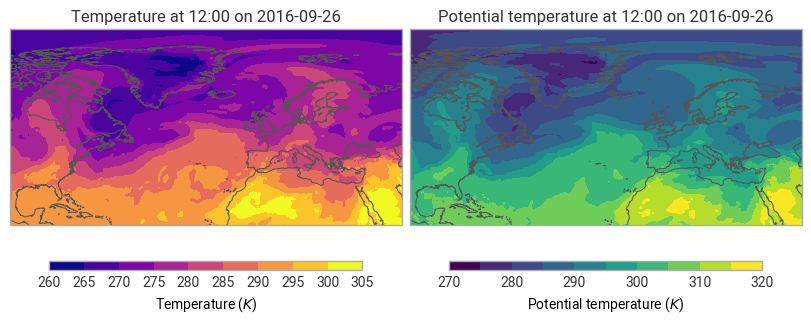

In [4]:
# select one level and step and plot input and resulting fields
t1 = ds.t.sel(pressure_level=850, valid_time="2016-09-26T12")
theta1 = theta.sel(pressure_level=850, valid_time="2016-09-26T12")

fig = ekp.Figure(rows=1, columns=2)

fig.add_map().contourf(t1, cmap="plasma")
fig.add_map().contourf(theta1, cmap="viridis")

fig.coastlines()
fig.subplot_titles()
fig.legend()

fig.show()

### Relative humidity

We compute the relative humidity with [earthkit.meteo.thermo.relative_humidity_from_specific_humidity](https://earthkit-meteo.readthedocs.io/en/release-1.0.0rc0/autoapi/earthkit/meteo/thermo/xarray/relative_humidity_from_specific_humidity.html#earthkit.meteo.thermo.xarray.relative_humidity_from_specific_humidity). The pressure requires the same treatment as above.

In [5]:
# input: temperature (K), specific humidity (kg/kg) and pressure (Pa)
r = thermo.relative_humidity_from_specific_humidity(ds.t,ds.q,ds.pressure_level*100.)
r

<xarray.DataArray 't' (valid_time: 4, pressure_level: 3, latitude: 301,
                       longitude: 601)> Size: 17MB
array([[[[97.54328644, 97.54328644, 97.54328644, ..., 97.54328644,
          97.54328644, 97.54328644],
         [97.65367699, 97.65367699, 97.65367699, ..., 97.64332812,
          97.62830064, 97.62830064],
         [97.77890701, 97.77887556, 97.77887556, ..., 97.36921791,
          97.35423724, 97.36941581],
         ...,
         [88.04107403, 84.58918343, 81.86065342, ..., 57.63399476,
          48.89488769, 52.02718373],
         [85.84192847, 83.48917503, 82.31186743, ..., 57.28587939,
          55.18957356, 58.8539121 ],
         [82.45719079, 82.636701  , 82.31443575, ..., 60.89282201,
          62.56367952, 62.84787417]],

        [[89.51893682, 89.51893682, 89.51893682, ..., 89.51893682,
          89.51893682, 89.51893682],
         [86.41668723, 86.36151799, 86.32017816, ..., 89.39759273,
          89.41107151, 89.39499912],
         [82.8593237 , 82.78117803, 82.70429261, ..., 90.00386201,
          90.00229189, 90.01505631],
...
         [85.56779375, 86.82882998, 88.80114898, ..., 36.89806384,
          38.98483343, 35.5264198 ],
         [85.68800891, 87.24602049, 89.44283015, ..., 56.8875422 ,
          65.57126579, 54.66459804],
         [85.69223016, 87.28621263, 89.25641133, ..., 43.91669021,
          32.42313   , 29.76044234]],

        [[69.91562068, 69.91562068, 69.91562068, ..., 69.91562068,
          69.91562068, 69.91562068],
         [66.29528978, 66.32500063, 66.3646193 , ..., 80.86144622,
          80.81233965, 80.77305126],
         [63.44568755, 63.52518399, 63.59474019, ..., 91.82596025,
          91.76738892, 91.71519374],
         ...,
         [76.31660021, 78.93669887, 84.96113891, ..., 48.72186866,
          50.22262284, 52.50791651],
         [77.06289466, 80.28259658, 86.28377925, ..., 51.57805874,
          53.6370266 , 55.93767418],
         [77.72679046, 81.53777628, 88.10593853, ..., 63.83202871,
          55.4424071 , 54.63659382]]]], shape=(4, 3, 301, 601))
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 32B 2016-09-26 ... 2016-09-26...
  * pressure_level  (pressure_level) float64 24B 925.0 850.0 700.0
  * latitude        (latitude) float64 2kB 90.0 89.75 89.5 ... 15.5 15.25 15.0
  * longitude       (longitude) float64 5kB -100.0 -99.75 -99.5 ... 49.75 50.0
Attributes: (12/31)
    GRIB_paramId:                             130
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      180901
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           t
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                Temperature
    units:                                    %
    standard_name:                            relative_humidity

We set the resulting metadata.

In [6]:
r.attrs["standard_name"] = "relative_humidity"
r.attrs["long_name"] = "Relative humidity"
r = r.rename("r")

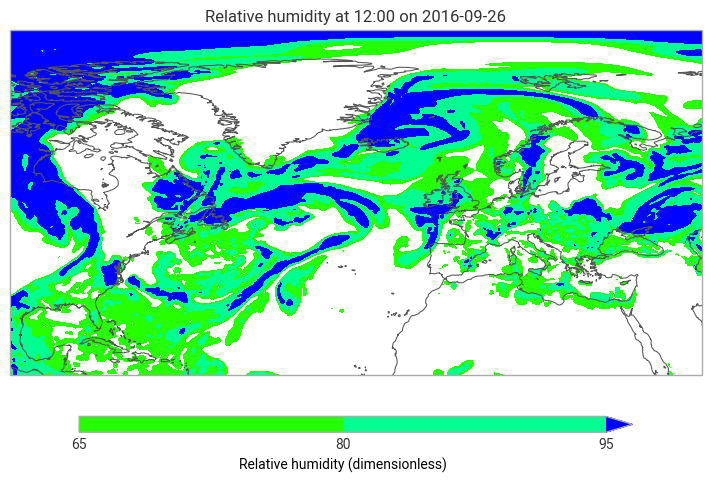

In [7]:
# plot one level and step from the results
r1 = r.sel(pressure_level=850, valid_time="2016-09-26T12")
ekp.quickplot(r1)